<a href="https://colab.research.google.com/github/RoseMaryBiju/Computer-Vision-Projects/blob/unit2/unit2_Automated_Industrial_Object_Counter_%26_Shape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

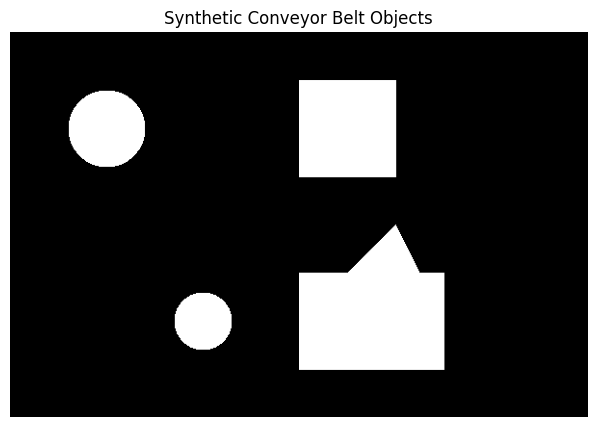

Number of Objects Detected: 4


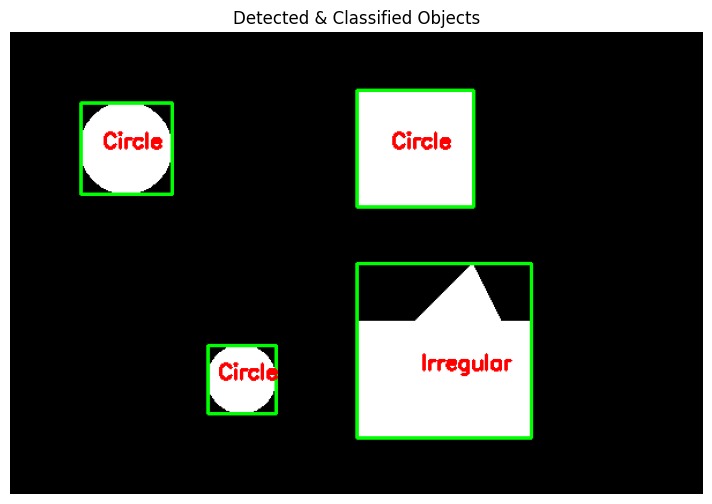


Region Properties:
Object 1: Area=10201.0, Perimeter=400.00, Centroid=(np.float64(100.0), np.float64(350.0)), Shape=Circle
Object 2: Area=5013.0, Perimeter=260.45, Centroid=(np.float64(100.0), np.float64(100.0)), Shape=Circle
Object 3: Area=17126.0, Perimeter=555.65, Centroid=(np.float64(292.6456849235081), np.float64(376.824710965783)), Shape=Irregular
Object 4: Area=2809.0, Perimeter=194.51, Centroid=(np.float64(300.0), np.float64(200.0)), Shape=Circle


In [ ]:
# -------------------------------
# UNIT-2 APPLICATION: Object Counting & Shape Recognition
# -------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, morphology, draw, color
from scipy.spatial import distance

# 1️⃣ Create synthetic conveyor belt image with multiple objects
image = np.zeros((400, 600), dtype=np.uint8)

# Draw circles
rr, cc = draw.disk((100, 100), 40)
image[rr, cc] = 255
rr, cc = draw.disk((300, 200), 30)
image[rr, cc] = 255

# Draw rectangles
rr, cc = draw.rectangle(start=(50, 400-100), end=(150, 500-100))  # avoid out-of-bounds
image[rr, cc] = 255
rr, cc = draw.rectangle(start=(250, 400-100), end=(350, 550-100))
image[rr, cc] = 255

# Draw triangle
rr, cc = draw.polygon([200, 250, 300], [400, 350, 450])
image[rr, cc] = 255

plt.figure(figsize=(8,5))
plt.title("Synthetic Conveyor Belt Objects")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

# 2️⃣ Connected Component Labeling
labeled = measure.label(image)
props = measure.regionprops(labeled)

# 3️⃣ Count Objects
print(f"Number of Objects Detected: {len(props)}")

# 4️⃣ Shape Classification (using circularity)
def classify_shape(region):
    perimeter = region.perimeter if region.perimeter != 0 else 1
    area = region.area
    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity > 0.8:
        return "Circle"
    elif len(region.convex_image[0]) / len(region.convex_image) > 1.5:
        return "Rectangle"
    else:
        return "Irregular"

# 5️⃣ Visualization with labels
image_rgb = color.gray2rgb(image)
for region in props:
    y0, x0 = region.centroid
    shape_name = classify_shape(region)
    minr, minc, maxr, maxc = region.bbox
    cv2.rectangle(image_rgb, (minc, minr), (maxc, maxr), (0,255,0), 2)
    cv2.putText(image_rgb, shape_name, (int(x0)-20,int(y0)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.figure(figsize=(10,6))
plt.title("Detected & Classified Objects")
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

# 6️⃣ Region Properties Extraction
print("\nRegion Properties:")
for i, region in enumerate(props, 1):
    print(f"Object {i}: Area={region.area}, Perimeter={region.perimeter:.2f}, Centroid={region.centroid}, Shape={classify_shape(region)}")